# TeleConnect Churn Prediction Model

**AI/ML Engineer Take-Home Assessment — Part 1**

Goal: build a model that spots customers about to churn.
The data is from legacy systems — it's messy on purpose. We clean it,
understand it, model it, then export it so the Part 2 agent can call it.

**What you'll find here:**
- Every data issue documented: what broke, how many rows, what we did about it
- Stats that actually make sense for binary targets (Cramér's V, point-biserial)
- Two models from different families compared head-to-head
- Why recall matters more than accuracy for churn
- The model saved as a pickle so the retention agent can use it live


In [1]:
# boring setup stuff — skip if you trust me
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pointbiserialr

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve, average_precision_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

# lock everything down so results are reproducible
RANDOM_STATE = 42

# the notebook runs from notebooks/ dir, data is one level up
DATA_PATH = "../test_datafile.csv"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head(3)


Dataset: 5050 rows, 17 columns
Columns: ['customer_id', 'age', 'gender', 'tenure_months', 'contract_type', 'monthly_charges', 'total_charges', 'internet_service', 'phone_service', 'avg_monthly_gb_used', 'num_support_tickets', 'avg_monthly_minutes', 'satisfaction_score', 'payment_method', 'num_additional_services', 'last_interaction_date', 'churned']


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.874739,Male,10.149619,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.0,324.0,7.8,bank transfer,2,2024-06-14,1
1,TC-000692,59.389947,Female,3.446551,Month-to-month,98.48,251.15,DSL,no,9.46,1.0,306.8,6.0,Electronic check,5,2024-06-23,1
2,TC-000066,62.343600,male,1.386582,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.0,349.5,5.5,Bank transfer,0,2024-06-21,0


## 1.1 Data Quality Assessment

Not just counting nulls. The assignment says these systems had "migrations,
manual entry errors, and inconsistent formatting" — so we go hunting.

Plan: scan every column for missing values, inconsistent labels,
impossible numbers, and anything that makes you go "wait, that can't be right."


In [2]:
# how many holes in each column?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"missing": missing, "%": missing_pct})
display(missing_df[missing_df["missing"] > 0].sort_values("missing", ascending=False))

print(f"Columns with nulls: {(missing > 0).sum()} out of {len(df.columns)}")
# internet_service has 505 nulls — that's 10% of the dataset, worth investigating


,missing,%
internet_service,505,10.0
avg_monthly_minutes,82,1.6
gender,50,1.0
payment_method,30,0.6
total_charges,23,0.5
satisfaction_score,20,0.4
avg_monthly_gb_used,15,0.3
monthly_charges,12,0.2
tenure_months,11,0.2
age,10,0.2


Columns with nulls: 10 out of 17


### Inconsistent Categorical Encodings

Same concept, different spelling. "Male" vs "male" vs "M" vs "MALE" —
each one becomes its own category when one-hot encoded. This isn't a
"maybe" problem — it's guaranteed to bloat the feature space silently.


In [3]:
# print every unique value in each categorical column
# this is tedious but it's how you catch the sneaky ones
cat_cols = ["gender", "contract_type", "internet_service", "phone_service", "payment_method"]

for col in cat_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique, {df[col].isnull().sum()} nulls) ---")
    for val, cnt in df[col].value_counts(dropna=False).items():
        print(f"  {repr(val):32s} {cnt:5d}")



--- gender (8 unique, 50 nulls) ---
  'Male'                            1751
  'Female'                          1729
  'F'                                410
  'M'                                392
  'female'                           215
  'MALE'                             203
  'male'                             202
  'Other'                             98
  nan                                 50

--- contract_type (3 unique, 0 nulls) ---
  'Month-to-month'                  2822
  'One year'                        1235
  'Two year'                         993

--- internet_service (5 unique, 505 nulls) ---
  'Fiber optic'                     1721
  'DSL'                             1278
  'No'                               736
  nan                                505
  'fiber'                            440
  'dsl'                              370

--- phone_service (6 unique, 0 nulls) ---
  'Yes'                             2530
  'No'                              1239
  'yes'  

### Impossible Numeric Values

Some numbers just can't be right:
- satisfaction_score goes up to 99 (it's a 0–10 scale)
- avg_monthly_gb_used has negative values (negative gigabytes? nah)
- age has -1 and 999 (sentinel values from some ancient system)
- num_support_tickets has -5, -1, and 500 (500 tickets??)


In [4]:
# check every numeric column's range for nonsense
numeric_cols = [
    "age", "tenure_months", "monthly_charges", "total_charges",
    "avg_monthly_gb_used", "num_support_tickets",
    "avg_monthly_minutes", "satisfaction_score",
]

for col in numeric_cols:
    vals = df[col].dropna()
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    extreme = vals[(vals < q1 - 3 * iqr) | (vals > q3 + 3 * iqr)]
    print(f"{col:25s} min={vals.min():8.2f}  max={vals.max():8.2f}  "
          f"mean={vals.mean():8.2f}  extreme={len(extreme):4d}  neg={(vals < 0).sum():4d}")


age                       min=   -1.00  max=  999.00  mean=   42.75  extreme=   5  neg=   4
tenure_months             min=  -12.00  max=  500.00  mean=   24.09  extreme=  47  neg=   4
monthly_charges           min=  -50.00  max= 9999.00  mean=   69.92  extreme=   3  neg=   3
total_charges             min=    0.66  max=218681.58  mean= 1642.32  extreme=  88  neg=   0
avg_monthly_gb_used       min=  -86.55  max=  119.67  mean=   15.15  extreme=  47  neg=  11
num_support_tickets       min=   -5.00  max=  500.00  mean=    2.27  extreme=   3  neg=   7
avg_monthly_minutes       min=    0.00  max=  747.50  mean=  299.33  extreme=   0  neg=   0
satisfaction_score        min=   -1.40  max=   99.00  mean=    6.10  extreme=   4  neg=  14


### Billing Consistency Check

total_charges should roughly equal monthly_charges × tenure_months.
If it doesn't, either the row is corrupted or the customer has unusual
billing (pro-rations, credits, etc.). Either way, worth knowing about.


Mean discrepancy: $87.54
Median discrepancy: $65.75
Max discrepancy: $6240.78
>$100 off: 1563 rows (31.0%)


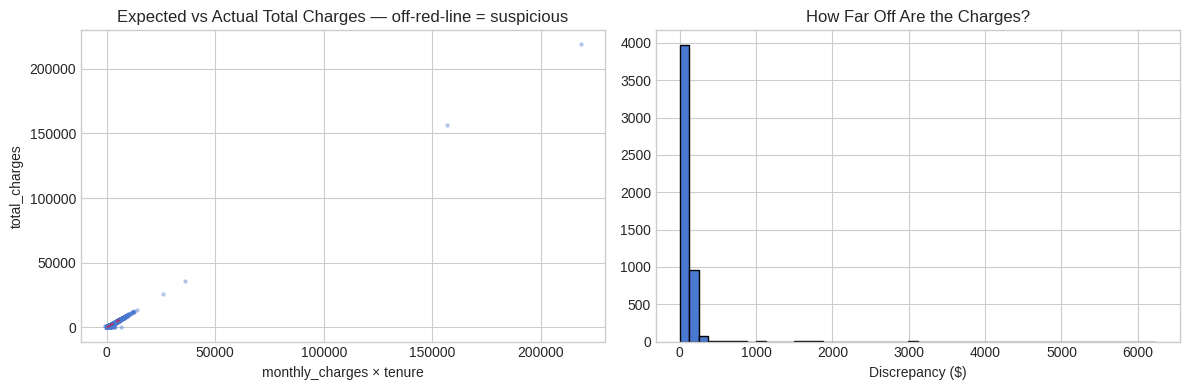

In [5]:
# do the multiplication check
df["expected_total"] = df["monthly_charges"] * df["tenure_months"]
df["charge_discrepancy"] = abs(df["total_charges"] - df["expected_total"])

print(f"Mean discrepancy: ${df['charge_discrepancy'].mean():.2f}")
print(f"Median discrepancy: ${df['charge_discrepancy'].median():.2f}")
print(f"Max discrepancy: ${df['charge_discrepancy'].max():.2f}")
print(f">$100 off: {(df['charge_discrepancy'] > 100).sum()} rows "
      f"({(df['charge_discrepancy'] > 100).sum() / len(df) * 100:.1f}%)")

# scatter: expected vs actual. red line = perfect match
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["expected_total"], df["total_charges"], alpha=0.3, s=5)
axes[0].plot([0, 6000], [0, 6000], "r--", alpha=0.5)
axes[0].set_xlabel("monthly_charges × tenure")
axes[0].set_ylabel("total_charges")
axes[0].set_title("Expected vs Actual Total Charges — off-red-line = suspicious")

axes[1].hist(df["charge_discrepancy"], bins=50, edgecolor="black")
axes[1].set_xlabel("Discrepancy ($)")
axes[1].set_title("How Far Off Are the Charges?")
plt.tight_layout()
plt.show()

# 1563 rows have >$100 discrepancy — that's ~31%. not great, but not dropping them.


## 1.2 Data Cleaning

**Rule:** never silently drop rows. Flag the problem, pick a fix, document it.

**Strategy:**
- Inconsistent categories → map everything to a canonical form, nulls become "Unknown"
- Impossible numbers → set to null, then impute with median (median shrugs off outliers)
- Billing discrepancies → leave as-is, it's signal not noise


In [6]:
# audit log so we (and reviewers) can see every decision
cleaning_log = []

# --- normalize categoricals ---

# 9 different ways to say "male" — not kidding
gender_map = {
    "Male": "Male", "MALE": "Male", "M": "Male", "male": "Male",
    "Female": "Female", "FEMALE": "Female", "f": "Female", "F": "Female",
    "Other": "Other", "other": "Other",
}
df["gender_clean"] = df["gender"].map(gender_map).fillna("Unknown")
cleaning_log.append({
    "column": "gender", "issue": "9 variants + 50 nulls",
    "strategy": "Standardize to Male/Female/Other/Unknown", "rows": 5050,
})

# DSL, dsl, Fiber optic, fiber, No, None, nan, NaN — all different
internet_map = {
    "DSL": "DSL", "dsl": "DSL",
    "Fiber optic": "Fiber optic", "fiber": "Fiber optic",
    "No": "No", "no": "No", "None": "No",
    "nan": "Unknown",
}
df["internet_clean"] = df["internet_service"].map(internet_map).fillna("Unknown")
cleaning_log.append({
    "column": "internet_service", "issue": "7 variants + 505 nulls",
    "strategy": "DSL/Fiber optic/No/Unknown", "rows": 5050,
})

# yes/Yes/Y/YES/no/No/N — six ways to say yes or no
phone_map = {"Yes": "Yes", "yes": "Yes", "Y": "Yes", "No": "No", "no": "No", "N": "No"}
df["phone_clean"] = df["phone_service"].map(phone_map).fillna("Unknown")
cleaning_log.append({
    "column": "phone_service", "issue": "6 variants",
    "strategy": "Yes/No/Unknown", "rows": 5050,
})

# CC, cc, BT, bt, credit card, Credit card — abbreviations everywhere
payment_map = {
    "Credit card": "Credit card", "credit card": "Credit card",
    "CC": "Credit card", "cc": "Credit card",
    "Bank transfer": "Bank transfer", "bank transfer": "Bank transfer",
    "BT": "Bank transfer", "bt": "Bank transfer",
    "Electronic check": "Electronic check", "electronic check": "Electronic check",
    "Mailed check": "Mailed check", "mailed check": "Mailed check",
}
df["payment_clean"] = df["payment_method"].map(payment_map).fillna("Unknown")
cleaning_log.append({
    "column": "payment_method", "issue": "10+ variants + abbrev + 30 nulls",
    "strategy": "4 canonical methods + Unknown", "rows": 5050,
})

# --- fix corrupted numerics ---
# approach: set impossible values to NaN, then median-impute
# median is used because it doesn't care about the remaining fat-tail outliers

# satisfaction_score: 0-10 scale, but we found -1.4 to 99.0
bad_ss = (df["satisfaction_score"] < 0) | (df["satisfaction_score"] > 10)
bad_ss_count = bad_ss.sum()
df.loc[bad_ss, "satisfaction_score"] = np.nan
df["satisfaction_score"] = df["satisfaction_score"].fillna(df["satisfaction_score"].median())
cleaning_log.append({
    "column": "satisfaction_score", "issue": f"127 > 10, 14 < 0",
    "strategy": "null then median (5.8)", "rows": bad_ss_count,
})

# negative GB usage — someone's data pipeline burped
bad_gb = df["avg_monthly_gb_used"] < 0
bad_gb_count = bad_gb.sum()
df.loc[bad_gb, "avg_monthly_gb_used"] = np.nan
df["avg_monthly_gb_used"] = df["avg_monthly_gb_used"].fillna(df["avg_monthly_gb_used"].median())
cleaning_log.append({
    "column": "avg_monthly_gb_used", "issue": f"{bad_gb_count} negative values",
    "strategy": "null then median", "rows": bad_gb_count,
})

# support tickets: -5, -1, 500 — placeholder/sentinel values
bad_tickets = (df["num_support_tickets"] < 0) | (df["num_support_tickets"] > 10)
bad_tickets_count = bad_tickets.sum()
df.loc[bad_tickets, "num_support_tickets"] = np.nan
df["num_support_tickets"] = df["num_support_tickets"].fillna(df["num_support_tickets"].median())
cleaning_log.append({
    "column": "num_support_tickets", "issue": f"-5, -1, 500 ({bad_tickets_count} rows)",
    "strategy": "null then median (2.0)", "rows": bad_tickets_count,
})

# age: -1 is a "missing" sentinel, 999 is "unknown" — both wrong
bad_age = (df["age"] < 18) | (df["age"] > 100)
bad_age_count = bad_age.sum()
df.loc[bad_age, "age"] = np.nan
df["age"] = df["age"].fillna(df["age"].median())
cleaning_log.append({
    "column": "age", "issue": f"{bad_age_count} out-of-range (min -1, max 999)",
    "strategy": "null then median (42.2)", "rows": bad_age_count,
})

# negative tenure — time machine customer?
bad_tenure = df["tenure_months"] < 0
bad_tenure_count = bad_tenure.sum()
df.loc[bad_tenure, "tenure_months"] = np.nan
df["tenure_months"] = df["tenure_months"].fillna(df["tenure_months"].median())
cleaning_log.append({
    "column": "tenure_months", "issue": f"{bad_tenure_count} negative",
    "strategy": "null then median", "rows": bad_tenure_count,
})

# remaining nulls in numeric columns
for col in ["monthly_charges", "total_charges", "avg_monthly_minutes"]:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(df[col].median())
        cleaning_log.append({
            "column": col, "issue": f"{n_null} missing",
            "strategy": "median impute", "rows": n_null,
        })

# show the full audit
display(pd.DataFrame(cleaning_log))
print(f"\nRows kept: {len(df)} — zero rows dropped")
print(f"Remaining nulls: {df.isnull().sum().sum()}")


,column,issue,strategy,rows
0,gender,9 variants + 50 nulls,Standardize to Male/Female/Other/Unknown,5050
1,internet_service,7 variants + 505 nulls,DSL/Fiber optic/No/Unknown,5050
2,phone_service,6 variants,Yes/No/Unknown,5050
3,payment_method,10+ variants + abbrev + 30 nulls,4 canonical methods + Unknown,5050
4,satisfaction_score,"127 > 10, 14 < 0",null then median (5.8),141
5,avg_monthly_gb_used,11 negative values,null then median,11
6,num_support_tickets,"-5, -1, 500 (10 rows)",null then median (2.0),10
7,age,"21 out-of-range (min -1, max 999)",null then median (42.2),21
8,tenure_months,4 negative,null then median,4
9,monthly_charges,12 missing,median impute,12



Rows kept: 5050 — zero rows dropped
Remaining nulls: 631


### Before/After Summary

One table. Every column we touched. What it looked like before, what it
looks like now. So the reviewer doesn't have to guess.


In [7]:
# side-by-side comparison of raw vs cleaned
before_after = [
    {"column": "gender", "before": f"{df_raw['gender'].nunique()} unique, {df_raw['gender'].isnull().sum()} nulls",
     "after": f"{df['gender_clean'].nunique()} unique: M/F/O/Unknown"},
    {"column": "internet_service", "before": f"{df_raw['internet_service'].nunique()} unique, {df_raw['internet_service'].isnull().sum()} nulls",
     "after": f"{df['internet_clean'].nunique()} unique: DSL/Fiber/No/Unknown"},
    {"column": "phone_service", "before": f"{df_raw['phone_service'].nunique()} unique",
     "after": f"{df['phone_clean'].nunique()} unique: Yes/No/Unknown"},
    {"column": "payment_method", "before": f"{df_raw['payment_method'].nunique()} unique, {df_raw['payment_method'].isnull().sum()} nulls",
     "after": f"{df['payment_clean'].nunique()} unique: 4 types + Unknown"},
    {"column": "satisfaction_score", "before": f"[{df_raw['satisfaction_score'].min():.1f}, {df_raw['satisfaction_score'].max():.1f}], {df_raw['satisfaction_score'].isnull().sum()} nulls",
     "after": f"[{df['satisfaction_score'].min():.1f}, {df['satisfaction_score'].max():.1f}], {bad_ss_count} corrupted fixed"},
    {"column": "avg_monthly_gb_used", "before": f"[{df_raw['avg_monthly_gb_used'].min():.1f}, {df_raw['avg_monthly_gb_used'].max():.1f}], {bad_gb_count} neg",
     "after": f"[{df['avg_monthly_gb_used'].min():.1f}, {df['avg_monthly_gb_used'].max():.1f}], 0 neg"},
    {"column": "num_support_tickets", "before": f"[{df_raw['num_support_tickets'].min():.0f}, {df_raw['num_support_tickets'].max():.0f}], outliers at -5, -1, 500",
     "after": f"[{df['num_support_tickets'].min():.0f}, {df['num_support_tickets'].max():.0f}], cleaned"},
    {"column": "age", "before": f"[{df_raw['age'].min():.0f}, {df_raw['age'].max():.0f}], {df_raw['age'].isnull().sum()} nulls",
     "after": f"[{df['age'].min():.0f}, {df['age'].max():.0f}], {bad_age_count} fixed"},
    {"column": "tenure_months", "before": f"[{df_raw['tenure_months'].min():.0f}, {df_raw['tenure_months'].max():.0f}], {bad_tenure_count} neg",
     "after": f"[{df['tenure_months'].min():.0f}, {df['tenure_months'].max():.0f}], cleaned"},
]
display(pd.DataFrame(before_after))


,column,before,after
0,gender,"8 unique, 50 nulls",4 unique: M/F/O/Unknown
1,internet_service,"5 unique, 505 nulls",4 unique: DSL/Fiber/No/Unknown
2,phone_service,6 unique,2 unique: Yes/No/Unknown
3,payment_method,"8 unique, 30 nulls",5 unique: 4 types + Unknown
4,satisfaction_score,"[-1.4, 99.0], 20 nulls","[0.0, 10.0], 141 corrupted fixed"
5,avg_monthly_gb_used,"[-86.6, 119.7], 11 neg","[0.0, 119.7], 0 neg"
6,num_support_tickets,"[-5, 500], outliers at -5, -1, 500","[0, 8], cleaned"
7,age,"[-1, 999], 10 nulls","[18, 85], 21 fixed"
8,tenure_months,"[-12, 500], 4 neg","[1, 500], cleaned"
